# Peyrache Lab — Raw Miniscope Imaging Tutorial

This notebook demonstrates how to access raw one-photon calcium imaging data from the Peyrache Lab dataset.

**Related dandiset**: [DANDI:001676](https://dandiarchive.org/dandiset/001676) (processed data: DF/F, ROI footprints, CellReg registration)

**Recording system**: UCLA Miniscope V4 (one-photon, GCaMP6f) implanted over the PostSubiculum of freely-moving mice.
Frames are synchronized to an Intan RHD hardware clock; raw video is stored as MJPEG-compressed AVI chunks.

**Reference**: Skromne Carrasco, S., Viejo, G. & Peyrache, A. *Months-long stability of the head-direction system.* Nature 652, 167–173 (2026). doi:10.1038/s41586-026-XXXX

## Table of Contents

1. [Setup and Data Access](#1-setup-and-data-access)
2. [Session and Subject Metadata](#2-session-and-subject-metadata)
3. [Imaging Metadata](#3-imaging-metadata)
4. [Raw Imaging Frames](#4-raw-imaging-frames)
5. [Synchronization Signals](#5-synchronization-signals)
6. [Behavior](#6-behavior)

## 1. Setup and Data Access

In [202]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import read_nwb

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [203]:
# Point this to a locally converted NWB file (produced by convert_session.py).
# stub: /Users/weian/nwb_output/peyrache/nwb_stub/sub-A0662_ses-2022-07-28_desc-raw_ophys.nwb
# full: /Users/weian/nwb_output/peyrache/sub-A0662_ses-2022-07-28_desc-raw_ophys.nwb
nwb_path = "/Users/weian/nwb_output/peyrache/sub-A0662_ses-2022-07-28_desc-raw_ophys.nwb"

nwbfile = read_nwb(nwb_path)

## 2. Session and Subject Metadata

In [204]:
print("=== Session ===")
print(f"  session_id          : {nwbfile.session_id}")
print(f"  session_start_time  : {nwbfile.session_start_time}")
print(f"  institution         : {nwbfile.institution}")
print(f"  lab                 : {nwbfile.lab}")
print()
print("=== Session description ===")
print(nwbfile.session_description)
print()
print("=== Experiment description ===")
print(nwbfile.experiment_description)

=== Session ===
  session_id          : 2022-07-28
  session_start_time  : 2022-07-28 00:00:00-04:00
  institution         : McGill University
  lab                 : Peyrache Lab

=== Session description ===
Raw one-photon calcium imaging (UCLA Miniscope V4) from the PostSubiculum of a freely moving mouse during a longitudinal head-direction cell recording. This NWB file contains raw acquisition data; corresponding processed data (DF/F, ROI footprints, CellReg registration) are available in DANDI:001676.


=== Experiment description ===
Longitudinal recording of GCaMP6f-expressing cells in the PostSubiculum of freely-moving C57BL/6J mice using a UCLA Miniscope V4 one-photon fluorescence microscope. Mice explored different environments over several months to characterise the long-term stability of head-direction cell representations. Behavioural position and head orientation were tracked simultaneously by an OptiTrack 3-D motion-capture system. An Intan RHD system recorded hardware syn

In [205]:
subject = nwbfile.subject
print("=== Subject ===")
print(f"  subject_id  : {subject.subject_id}")
print(f"  species     : {subject.species}")
print(f"  genotype    : {subject.genotype}")
print(f"  sex         : {subject.sex}")
if subject.date_of_birth:
    print(f"  date_of_birth: {subject.date_of_birth.date()}")
print(f"  description : {subject.description}")

=== Subject ===
  subject_id  : A0662
  species     : Mus musculus
  genotype    : C57BL/6J
  sex         : M
  description : Adult male C57BL/6J mouse implanted with a UCLA Miniscope V4 head-mounted fluorescence microscope for longitudinal calcium imaging of PostSubiculum head-direction cells.



## 3. Imaging Metadata

The `ImagingPlane` object stores device configuration, excitation/emission wavelengths, pixel pitch, and anatomical coordinates.
These values come directly from the Miniscope `metaData.json` and from lab-confirmed metadata.

In [206]:
imaging_plane = nwbfile.imaging_planes["ImagingPlane"]

print("=== ImagingPlane ===")
print(f"  name                : {imaging_plane.name}")
print(f"  description         : {imaging_plane.description}")
print(f"  location            : {imaging_plane.location}")
print(f"  indicator           : {imaging_plane.indicator}")
print(f"  excitation_lambda   : {imaging_plane.excitation_lambda} nm")
print(f"  grid_spacing        : {imaging_plane.grid_spacing[:]} {imaging_plane.grid_spacing_unit}")
if imaging_plane.origin_coords is not None:
    print(f"  origin_coords       : {imaging_plane.origin_coords[:]} {imaging_plane.origin_coords_unit}  (AP, ML, DV from bregma)")
print()

print("=== Optical Channels ===")
for ch in imaging_plane.optical_channel:
    print(f"  {ch.name}: emission_lambda={ch.emission_lambda} nm")
    print(f"    {ch.description}")
print()

print("=== Device ===")
device = imaging_plane.device
print(f"  name         : {device.name}")
print(f"  description  : {device.description}")
print(f"  manufacturer : {device.manufacturer}")

=== ImagingPlane ===
  name                : ImagingPlane
  description         : Longitudinal recording of cells in the PostSubiculum
  location            : PostSubiculum
  indicator           : GCaMP6f
  excitation_lambda   : 470.0 nm
  grid_spacing        : [0.0033 0.0033] millimeters
  origin_coords       : [-2.35  0.32 -1.3 ] millimeters  (AP, ML, DV from bregma)

=== Optical Channels ===
  GreenChannel: emission_lambda=525.0 nm
    Green emission channel for GCaMP6f fluorescence detection

=== Device ===
  name         : 1p Miniscope
  description  : UCLA Miniscope V4
  manufacturer : UCLA / Open Ephys


## 4. Raw Imaging Frames

The `OnePhotonSeries` stores the raw calcium imaging video.
Data are originally recorded as MJPEG-compressed AVI chunks (2,000 frames each); NeuroConv assembles them into a single `OnePhotonSeries` object backed by a lazy reader.

**Important**: timestamps are hardware-derived (from the Intan sync channel, see Section 5) rather than from the Miniscope USB clock, which has ±236 ms jitter.

In [207]:
ops = nwbfile.acquisition["OnePhotonSeries"]

n_frames, height, width = ops.data.shape
timestamps = ops.timestamps[:]
duration_s = timestamps[-1] - timestamps[0]
actual_fps = (len(timestamps) - 1) / duration_s

print("=== OnePhotonSeries ===")
print(f"  shape           : {ops.data.shape}  (frames × height × width)")
print(f"  dtype           : {ops.data.dtype}")
print(f"  unit            : {ops.unit}")
print(f"  n_frames        : {n_frames:,}")
print(f"  frame size      : {height} × {width} px")
print(f"  t_start         : {timestamps[0]:.3f} s  (relative to Intan clock start)")
print(f"  t_end           : {timestamps[-1]:.3f} s")
print(f"  duration        : {duration_s:.1f} s  ({duration_s/60:.1f} min)")
print(f"  actual FPS      : {actual_fps:.4f} Hz  (nominal 25 Hz)")
print(f"  description     : {ops.description}")

=== OnePhotonSeries ===
  shape           : (29568, 608, 608)  (frames × height × width)
  dtype           : uint8
  unit            : px
  n_frames        : 29,568
  frame size      : 608 × 608 px
  t_start         : 1.857 s  (relative to Intan clock start)
  t_end           : 1201.918 s
  duration        : 1200.1 s  (20.0 min)
  actual FPS      : 24.6379 Hz  (nominal 25 Hz)
  description     : Raw calcium imaging video from a UCLA Miniscope V4 one-photon fluorescence microscope. Data are acquired as MJPEG-compressed AVI chunks (2 000 frames each). Timestamps are derived from the Intan hardware sync channel (ADC-01, Miniscope frame-gate square wave).



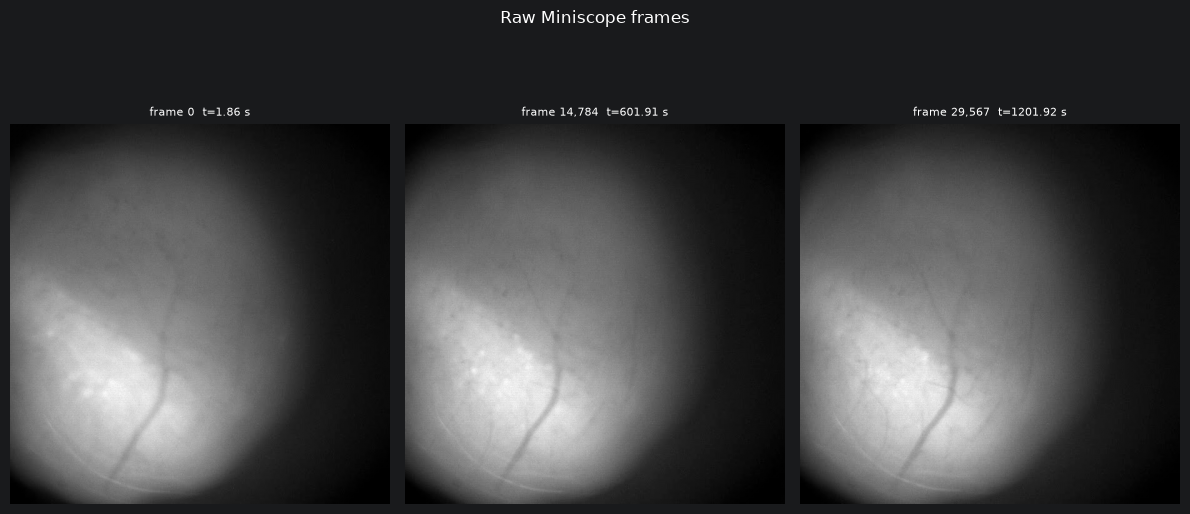

In [208]:
fig, axes = plt.subplots(1, 3)
tile_indices = [0, n_frames // 2, n_frames - 1]
for ax, idx in zip(axes.flat, tile_indices):
    ax.imshow(ops.data[idx], cmap="gray", aspect="equal")
    ax.set_title(f"frame {idx:,}  t={timestamps[idx]:.2f} s", fontsize=8)
    ax.axis("off")

fig.suptitle("Raw Miniscope frames", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Synchronization Signals

The `TimeSeriesIntanSync` object stores both ADC input channels from the Intan RHD system at 20 kHz.
It uses `rate` + `starting_time` (no per-sample timestamps array) because the Intan clock is perfectly regular.

| Channel | ADC name | Signal | Frequency | Pulse width |
|---------|----------|--------|-----------|-------------|
| 0 | ADC-00 | **OptiTrack sync** | 120 Hz | 0.5 ms TTL pulse per frame |
| 1 | ADC-01 | **Miniscope frame gate** | ~12.3 Hz (2-frame cycle) | 40.6 ms per half-period |

**Key finding**: The Miniscope frame gate (ADC-01) is a square wave whose rising edge marks even frames (0, 2, 4, …) and falling edge marks odd frames (1, 3, 5, …).  
The `OnePhotonSeries.timestamps` are already decoded from this signal. This section shows the raw waveforms and validates the decoding.

In [209]:
sync_ts = nwbfile.acquisition["TimeSeriesIntanSync"]

# Reconstruct sample times from rate + starting_time (no per-sample timestamps stored)
n_sync_samples = sync_ts.data.shape[0]
t0 = sync_ts.starting_time if sync_ts.starting_time is not None else 0.0
t_intan = t0 + np.arange(n_sync_samples) / sync_ts.rate

# Raw uint16 ADC data (0–65535 → 0–3.3 V)
adc_raw = sync_ts.data[:]          # shape (n_samples, 2), dtype uint16
adc_v   = adc_raw * (3.3 / 65535)  # convert to volts for plotting

print("=== TimeSeriesIntanSync ===")
print(f"  shape         : {sync_ts.data.shape}  (samples × channels)")
print(f"  rate          : {sync_ts.rate:.0f} Hz")
print(f"  starting_time : {t0:.3f} s")
print(f"  duration      : {t_intan[-1] - t_intan[0]:.2f} s")
print(f"  description   : {sync_ts.description}")

=== TimeSeriesIntanSync ===
  shape         : (24158160, 2)  (samples × channels)
  rate          : 20000 Hz
  starting_time : 0.000 s
  duration      : 1207.91 s
  description   : Intan RHD ADC input channels used for hardware synchronisation. Channel 0 (ADC-00): OptiTrack sync — 120 Hz TTL pulses (0.5 ms width), one rising edge per OptiTrack frame. Channel 1 (ADC-01): Miniscope frame gate — square wave where each half-period (≈ 40.6 ms) spans one Miniscope frame; rising edge = even frame (0, 2, 4, …), falling edge = odd frame (1, 3, 5, …). Both edges are decoded to produce the per-frame hardware timestamps stored in OnePhotonSeries.



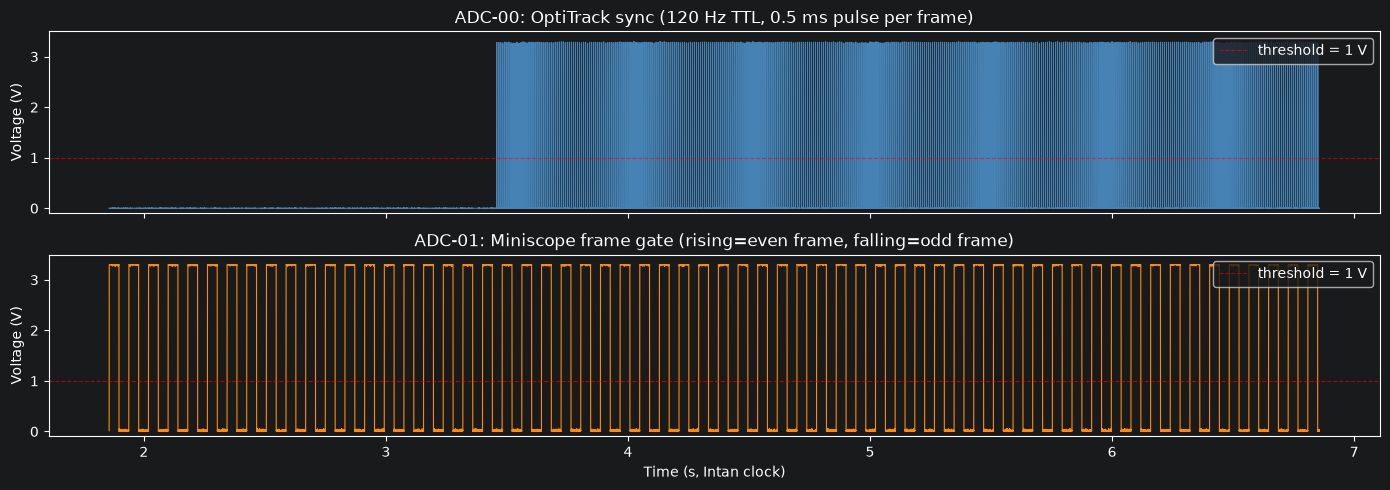

In [210]:
# Visualise a 5-second window of the sync waveforms (in volts)
t_start_plot = miniscope_timestamps_hw[0]
t_end_plot   = t_start_plot + 5.0
mask = (t_intan >= t_start_plot) & (t_intan <= t_end_plot)

THRESH_V = 1.0  # display threshold in volts

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t_intan[mask], adc_v[mask, 0], color="steelblue", lw=0.8)
axes[0].axhline(THRESH_V, color="red", lw=0.8, ls="--", alpha=0.6, label="threshold = 1 V")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("ADC-00: OptiTrack sync (120 Hz TTL, 0.5 ms pulse per frame)")
axes[0].set_ylim(-0.1, 3.5)
axes[0].legend(loc="upper right")

axes[1].plot(t_intan[mask], adc_v[mask, 1], color="darkorange", lw=0.8)
axes[1].axhline(THRESH_V, color="red", lw=0.8, ls="--", alpha=0.6, label="threshold = 1 V")
axes[1].set_ylabel("Voltage (V)")
axes[1].set_title("ADC-01: Miniscope frame gate (rising=even frame, falling=odd frame)")
axes[1].set_xlabel("Time (s, Intan clock)")
axes[1].set_ylim(-0.1, 3.5)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [211]:
# Session timeline
t_intan_start = t_intan[0]
t_intan_end   = t_intan[-1]
t_ms_start    = miniscope_timestamps_hw[0]
t_ms_end      = miniscope_timestamps_hw[-1]
t_ot_start    = tracking_timestamps[0]
t_ot_end      = tracking_timestamps[-1]

print("=== Session timeline (Intan master clock, t=0 = Intan start) ===")
print(f"  t = {t_intan_start:9.3f} s   Intan recording starts")
print(f"  t = {t_ms_start:9.3f} s   Miniscope frame 0 (first Ch1 rising edge)")
print(f"  t = {t_ot_start:9.3f} s   OptiTrack frame 0 (first Ch0 rising edge)")
print(f"  t = {t_ms_end:9.3f} s   Last Miniscope hardware sync pulse")
print(f"  t = {t_ot_end:9.3f} s   Last synced OptiTrack frame")
print(f"  t = {t_intan_end:9.3f} s   Intan recording ends")
print()
overlap_start = max(t_ms_start, t_ot_start)
overlap_end   = min(t_ms_end, t_ot_end)
print(f"  Overlap (all systems synced): {overlap_start:.2f} – {overlap_end:.2f} s "
      f"({overlap_end - overlap_start:.1f} s = {(overlap_end - overlap_start)/60:.1f} min)")

=== Session timeline (Intan master clock, t=0 = Intan start) ===
  t =     0.000 s   Intan recording starts
  t =     1.857 s   Miniscope frame 0 (first Ch1 rising edge)
  t =     3.458 s   OptiTrack frame 0 (first Ch0 rising edge)
  t =  1201.918 s   Last Miniscope hardware sync pulse
  t =  1207.098 s   Last synced OptiTrack frame
  t =  1207.908 s   Intan recording ends

  Overlap (all systems synced): 3.46 – 1201.92 s (1198.5 s = 20.0 min)


In [212]:
# Cross-system alignment summary
print("=== Cross-system alignment summary ===")
print(f"  Miniscope  : {len(timestamps):,} frames  ({timestamps[0]:.2f} – {timestamps[-1]:.2f} s)")
print(f"  OptiTrack  : {len(tracking_timestamps):,} frames  ({tracking_timestamps[0]:.2f} – {tracking_timestamps[-1]:.2f} s)")
print(f"  Intan ADC  : {n_sync_samples:,} samples  ({t_intan[0]:.2f} – {t_intan[-1]:.2f} s)  @ {sync_ts.rate:.0f} Hz")

overlap_s = min(timestamps[-1], tracking_timestamps[-1]) - max(timestamps[0], tracking_timestamps[0])
print(f"\n  Miniscope ∩ OptiTrack overlap: {overlap_s:.1f} s ({overlap_s/60:.1f} min)")

=== Cross-system alignment summary ===
  Miniscope  : 29,568 frames  (1.86 – 1201.92 s)
  OptiTrack  : 144,444 frames  (3.46 – 1207.10 s)
  Intan ADC  : 24,158,160 samples  (0.00 – 1207.91 s)  @ 20000 Hz

  Miniscope ∩ OptiTrack overlap: 1198.5 s (20.0 min)


In [213]:
nwbfile.read_io.close()